L2 Risk-Based Pricing Strategy
**Core question:** *What rate should each loan carry to cover funding cost, operating cost, expected loss, and target margin?*

## Data Sources
| File | Source | Purpose |
|---|---|---|
| `l1_el_breakdown.csv` | Shuxin| 2018Q4 active loan EAD / segment counts / L1 EL benchmark by grade × term × purpose |
| `pd_predictions.csv` | Patton| Direct loan-level predicted PD and actual interest rate (source of pricing PD) |
| `accepted_2007_to_2018Q4.csv` | Raw data | Optional fallback source for missing interest-rate fields |

## Why 2018Q4 Active Portfolio
We use the 2018Q4 active portfolio as a **risk-return snapshot** to evaluate whether
historical pricing adequately compensated investors for expected loss. The resulting
pricing rules are intended for **future origination / portfolio selection**, not literal
repricing of already issued fixed-rate loans.


## 0. Imports & Style

In [44]:
import warnings

warnings.filterwarnings("ignore")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from scipy import stats
from matplotlib.patches import Patch

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 11,
    }
)

NAVY = "#1B3A6B"
TEAL = "#2E8B8B"
ORANGE = "#E07B39"
RED = "#C0392B"
GREEN = "#27AE60"
GRAY = "#95A5A6"

print("Libraries loaded.")

Libraries loaded.


## 1. Paths & Constants

### Parameter rationale
| Parameter | Value | Basis |
|---|---|---|
| `FUNDING_COST` | 3.5% | 3-yr Treasury (~2.5%) + LC platform spread (~1%), 2016-2018 |
| `OP_COST` | 1.0% | LC asset-light model; traditional banks ~2-3% |
| `TARGET_MARGIN` | 1.5% | Mid-range of typical consumer lending margin (1-2%) |
| `HURDLE_RATE` | 12% | Project convention (framework one-pager), aligned with L4 |
| `USURY_CAP` | 30% | Conservative proxy across US state usury laws (18-36% range) |
| `REPRICE_THRESH` | -50bp | Gaps within ±50bp treated as noise / model uncertainty |
| `GROW_THRESH` | +50bp | Same — industry practice typically 25-100bp |
| `K_VaR` | 3.5 | Basel IRB approximation for 99.9% VaR confidence |
| `MIN_N` | 30 | Minimum loans per segment for reliable confidence interval |

In [45]:
L1_BREAKDOWN = Path(
    "/Users/yumengfang/Desktop/583_project/pricing strategy final/data/l1_el_breakdown.csv"
)
PD_FILE = Path(
    "/Users/yumengfang/Desktop/583_project/pricing strategy final/data/pd_predictions.csv"
)
RAW_PATH = Path(
    "/Users/yumengfang/Desktop/583_project/pricing strategy final/data/accepted_2007_to_2018Q4.csv"
)
OUT_DIR = Path(
    "/Users/yumengfang/Desktop/583_project/pricing strategy final/data/output"
)
FIG_DIR = Path(
    "/Users/yumengfang/Desktop/583_project/pricing strategy final/data/output/figures"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

LGD_CONST = 0.9013
FUNDING_COST = 0.035
OP_COST = 0.010
TARGET_MARGIN = 0.015
HURDLE_RATE = 0.12
USURY_CAP = 0.30
REPRICE_THRESH = -0.005
GROW_THRESH = 0.005
K_VaR = 3.5
MIN_N = 30
CI_LEVEL = 0.95
Z_SCORE = stats.norm.ppf(1 - (1 - CI_LEVEL) / 2)

ACTIVE_STATUSES = [
    "Current",
    "In Grace Period",
    "Late (16-30 days)",
    "Late (31-120 days)",
]
PD_COL_CANDIDATES = [
    "pd_12m",
    "PD_12m",
    "predicted_pd",
    "default_probability",
    "pd",
    "PD",
    "pred_pd",
    "prob_default",
    "p_default",
    "y_pred_proba",
    "default_prob",
    "predicted_probability",
    "probability_default",
]
EAD_COL_CANDIDATES = ["out_prncp", "funded_amnt", "loan_amnt"]

## 2. Data Loading & Preparation

### Strategy
- Segment frame from `l1_el_breakdown.csv` (`grade`, `term_num`, `purpose`, `ead`, `n`).
- Rename L1 EL to `el_12m_l1`; keep only as reference.
- Segment-level `avg_pd` is aggregated from loan-level predicted PD in `pd_predictions.csv`.
- Segment-level rate is aggregated from loan-level `int_rate` in `pd_predictions.csv`.


In [46]:
df = pd.read_csv(L1_BREAKDOWN)
if "el_12m" in df.columns:
    df = df.rename(columns={"el_12m": "el_12m_l1"})

print(f"L1 breakdown : {len(df):,} segments")
print(f"Total EAD    : ${df['ead'].sum()/1e9:.2f}B")
if "el_12m_l1" in df.columns:
    print(f"L1 EL ref    : ${df['el_12m_l1'].sum()/1e6:.1f}M")

L1 breakdown : 170 segments
Total EAD    : $9.51B
L1 EL ref    : $480.8M


In [47]:
def parse_percent_or_decimal(series, col_name="value"):
    s = series.astype(str).str.replace("%", "", regex=False).str.strip()
    x = pd.to_numeric(s, errors="coerce")
    x = pd.Series(x, index=series.index, name=col_name)
    return x.where(x <= 1, x / 100)


def detect_pd_column(pdf):
    cols = set(pdf.columns)
    explicit_priority = ["pd_12m", "PD_12m", "predicted_pd", "default_probability"]
    for c in explicit_priority:
        if c in cols:
            return c
    for c in PD_COL_CANDIDATES:
        if c in cols:
            return c
    raise ValueError(f"No PD column found. Available columns: {list(pdf.columns)}")


pd_df = pd.read_csv(PD_FILE)
print(f"pd_predictions columns: {pd_df.columns.tolist()}")
PD_COL = "pd_12m_logit"
print(f"PD column: {PD_COL}")

# term_num already exists in pd_predictions.csv (numeric: 36.0 / 60.0)
# no need to parse from 'term' column
if "term_num" not in pd_df.columns and "term" in pd_df.columns:
    pd_df["term_num"] = pd_df["term"].astype(str).str.extract(r"(\d+)").astype(float)
pd_df["int_rate_dec"] = parse_percent_or_decimal(pd_df["int_rate"], "int_rate_dec")
pd_df["pd_dec"] = parse_percent_or_decimal(pd_df[PD_COL], "pd_dec")

print(f"Missing PD: {pd_df['pd_dec'].isna().sum():,}")
print(f"Missing int_rate: {pd_df['int_rate_dec'].isna().sum():,}")
print(
    f"PD min/max/mean: {pd_df['pd_dec'].min():.4f}/{pd_df['pd_dec'].max():.4f}/{pd_df['pd_dec'].mean():.4f}"
)
print(
    f"Rate min/max/mean: {pd_df['int_rate_dec'].min():.4f}/{pd_df['int_rate_dec'].max():.4f}/{pd_df['int_rate_dec'].mean():.4f}"
)

active_pd = pd_df[pd_df["loan_status"].isin(ACTIVE_STATUSES)].copy()
exposure_col = next((c for c in EAD_COL_CANDIDATES if c in active_pd.columns), None)
if exposure_col is not None:
    active_pd["ead_weight"] = pd.to_numeric(
        active_pd[exposure_col], errors="coerce"
    ).clip(lower=0)
    active_pd.loc[
        active_pd["ead_weight"].isna() | (active_pd["ead_weight"] <= 0), "ead_weight"
    ] = np.nan
    PD_AGG_METHOD = f"EAD-weighted ({exposure_col})"
else:
    active_pd["ead_weight"] = 1.0
    PD_AGG_METHOD = "Unweighted mean"
    print("NOTE: no exposure column found; using unweighted segment means.")

agg_base = active_pd.dropna(
    subset=["pd_dec", "int_rate_dec", "grade", "term_num", "purpose"]
).copy()
segment_agg = (
    agg_base.groupby(["grade", "term_num", "purpose"])
    .apply(
        lambda x: pd.Series(
            {
                "avg_pd": np.average(x["pd_dec"], weights=x["ead_weight"]),
                "std_pd": x["pd_dec"].std(),
                "n_pd": x["pd_dec"].count(),
                "avg_intrate": np.average(x["int_rate_dec"], weights=x["ead_weight"]),
                "std_intrate": x["int_rate_dec"].std(),
                "n_intrate": x["int_rate_dec"].count(),
            }
        )
    )
    .reset_index()
)

df = df.merge(segment_agg, on=["grade", "term_num", "purpose"], how="left")
missing_pd = df["avg_pd"].isna()
missing_rate = df["avg_intrate"].isna()
print(f"L1 segments: {len(df):,}")
print(f"PD segments: {len(segment_agg):,}")
print(f"Missing avg_pd: {missing_pd.sum():,} ({missing_pd.mean():.1%})")
print(f"Missing avg_intrate: {missing_rate.sum():,} ({missing_rate.mean():.1%})")
print(
    f"EAD share missing avg_pd: {df.loc[missing_pd, 'ead'].sum()/df['ead'].sum():.2%}"
)
print(
    f"EAD share missing avg_intrate: {df.loc[missing_rate, 'ead'].sum()/df['ead'].sum():.2%}"
)

df = df.dropna(subset=["avg_pd", "avg_intrate"]).copy()

pd_predictions columns: ['id', 'grade', 'issue_d', 'loan_status', 'loan_amnt', 'int_rate', 'annual_inc', 'dti', 'fico_avg', 'term_num', 'addr_state', 'purpose', 'home_ownership', 'installment', 'emp_length', 'pd_6m_logit', 'pd_12m_logit', 'pd_18m_logit', 'pd_24m_logit', 'pd_6m_rf', 'pd_12m_rf', 'pd_18m_rf', 'pd_24m_rf', 'pd_6m_cox_raw', 'pd_18m_cox_raw', 'pd_24m_cox_raw', 'pd_24m_cox', 'pd_36m_cox_raw', 'pd_36m_cox', 'pd_60m_cox_raw', 'pd_60m_cox', 'pd_24m_chosen']
PD column: pd_12m_logit
Missing PD: 0
Missing int_rate: 0
PD min/max/mean: 0.0000/1.0000/0.0553
Rate min/max/mean: 0.0531/0.3099/0.1309
L1 segments: 170
PD segments: 170
Missing avg_pd: 0 (0.0%)
Missing avg_intrate: 0 (0.0%)
EAD share missing avg_pd: 0.00%
EAD share missing avg_intrate: 0.00%


In [48]:
print("Data ready. Sample:")
print(
    df[
        [
            "grade",
            "term_num",
            "purpose",
            "n",
            "ead",
            "avg_pd",
            "avg_intrate",
            "std_intrate",
            "n_intrate",
        ]
    ]
    .head(10)
    .to_string(index=False)
)

Data ready. Sample:
grade  term_num            purpose     n          ead   avg_pd  avg_intrate  std_intrate  n_intrate
    A      36.0                car  2245  11535787.29 0.022315     0.068934     0.009676     2245.0
    A      36.0        credit_card 59181 554328790.81 0.023040     0.069024     0.009820    59181.0
    A      36.0 debt_consolidation 82255 838613323.61 0.027475     0.070318     0.009611    82255.0
    A      36.0   home_improvement 14425 122433242.34 0.023116     0.067744     0.009874    14425.0
    A      36.0              house  1525  15395037.25 0.027166     0.068206     0.009392     1525.0
    A      36.0     major_purchase  4457  33485360.24 0.026722     0.068859     0.009544     4457.0
    A      36.0            medical  2327  13043872.32 0.031352     0.069508     0.009402     2327.0
    A      36.0             moving   886   5170181.73 0.040049     0.069691     0.009362      886.0
    A      36.0              other 10222  71193613.51 0.027718     0.069645     

## 3.1 Deliverable 1 — Required Rate Formula (Fully Decomposed)

r_req = funding cost + operating cost + PD × LGD + target margin.

PD comes directly from `pd_predictions.csv`; `el_12m_l1` is reference only.
Capital charge is not directly added to loan pricing; RAROC is used as a separate capital-efficiency check.


In [49]:
df["el_premium"] = df["avg_pd"] * LGD_CONST
df["el_rate"] = df["el_premium"]
df["el_12m_model"] = df["el_premium"] * df["ead"]

df["r_req_raw"] = FUNDING_COST + OP_COST + df["el_premium"] + TARGET_MARGIN
df["above_usury_cap"] = df["r_req_raw"] > USURY_CAP

# Use r_req_raw (uncapped) for gap calculation so Decline segments
# are not artificially inflated. r_req_display is capped for presentation only.
df["r_req"] = df["r_req_raw"]  # uncapped — correct for gap math
df["r_req_display"] = df["r_req_raw"].clip(upper=USURY_CAP)  # capped — for charts
df["pricing_gap"] = df["avg_intrate"] - df["r_req"]

df["ul"] = df["ead"] * LGD_CONST * np.sqrt(df["avg_pd"] * (1 - df["avg_pd"]))
df["ec"] = df["ul"] * K_VaR
df["revenue"] = df["avg_intrate"] * df["ead"]
df["funding$"] = FUNDING_COST * df["ead"]
df["opex$"] = OP_COST * df["ead"]
df["el$"] = df["el_12m_model"]
df["net_income"] = df["revenue"] - df["funding$"] - df["opex$"] - df["el$"]
df["raroc"] = (df["net_income"] / df["ec"]).clip(-1, 2)

w = df["ead"]
print("=== Pricing Decomposition (EAD-weighted portfolio averages) ===")
print(f"  Funding cost (r_funding)   : {FUNDING_COST:.2%}")
print(f"  Op cost (r_opex)           : {OP_COST:.2%}")
print(f"  EL premium (PD×LGD)        : {(df['el_premium']*w).sum()/w.sum():.2%}")
print(f"  Target margin              : {TARGET_MARGIN:.2%}")
print(f"  {'─'*42}")
print(f"  r_req  (portfolio avg)     : {(df['r_req']*w).sum()/w.sum():.2%}")
print(f"  r_lc   (LC actual avg)     : {(df['avg_intrate']*w).sum()/w.sum():.2%}")
print(f"  Pricing gap (avg)          : {(df['pricing_gap']*w).sum()/w.sum():.2%}")
print(f"  Above usury cap (30%)      : {df['above_usury_cap'].sum()} segments")
print()

# Directionality check
grade_gaps = (
    df.groupby("grade")
    .apply(lambda x: np.average(x["pricing_gap"], weights=x["ead"]))
    .reindex(["A", "B", "C", "D", "E", "F", "G"])
)
is_monotone = all(
    grade_gaps.iloc[i] >= grade_gaps.iloc[i + 1] for i in range(len(grade_gaps) - 1)
)
print("=== Directionality Check: EAD-weighted avg gap by grade ===")
print(f"(Monotonically decreasing A→G: {is_monotone})")
for g, v in grade_gaps.items():
    bar = "▓" * int(abs(v) * 200) if v > 0 else "░" * int(abs(v) * 200)
    print(f"  Grade {g}: {v:+.2%}  {bar}")

=== Pricing Decomposition (EAD-weighted portfolio averages) ===
  Funding cost (r_funding)   : 3.50%
  Op cost (r_opex)           : 1.00%
  EL premium (PD×LGD)        : 4.92%
  Target margin              : 1.50%
  ──────────────────────────────────────────
  r_req  (portfolio avg)     : 10.92%
  r_lc   (LC actual avg)     : 13.06%
  Pricing gap (avg)          : 2.15%
  Above usury cap (30%)      : 10 segments

=== Directionality Check: EAD-weighted avg gap by grade ===
(Monotonically decreasing A→G: False)
  Grade A: -1.18%  ░░
  Grade B: +1.37%  ▓▓
  Grade C: +3.33%  ▓▓▓▓▓▓
  Grade D: +4.86%  ▓▓▓▓▓▓▓▓▓
  Grade E: +5.25%  ▓▓▓▓▓▓▓▓▓▓
  Grade F: +4.17%  ▓▓▓▓▓▓▓▓
  Grade G: +1.82%  ▓▓▓


### Interpretation

**Pricing Decomposition:** The portfolio-level required rate is 10.92%, compared with LendingClub’s average actual rate of 13.06%. This implies a positive average pricing gap of +215bp, suggesting that observed rates generally cover required rates. However, 10 segments have raw required rates above the 30% usury-cap proxy and are therefore flagged for decline / non-origination rather than repricing.

**Directionality Check:** The pricing gap is not monotonically decreasing from Grade A to Grade G. Grade A is the only underpriced grade, with a gap of −1.18%, which may reflect competitive rate compression among prime borrowers. Grades B–E show large positive gaps, peaking at Grade E (+5.25%), suggesting stronger risk-adjusted pricing in mid-risk segments.

**High-risk Segment Implication:** Although Grades F–G still have positive gaps, the gap narrows after Grade E, falling to +4.17% for F and +1.82% for G. This suggests that high-risk loans are relatively less compensated than mid-risk loans.

These findings support the three-bucket strategy in §3.3: Grade A may require upward rate adjustment or tighter approval standards; B–E may be growth candidates conditional on RAROC and significance checks; and F–G should be monitored carefully, with repricing or decline decisions depending on RAROC, usury-cap constraints, and confidence-interval results.

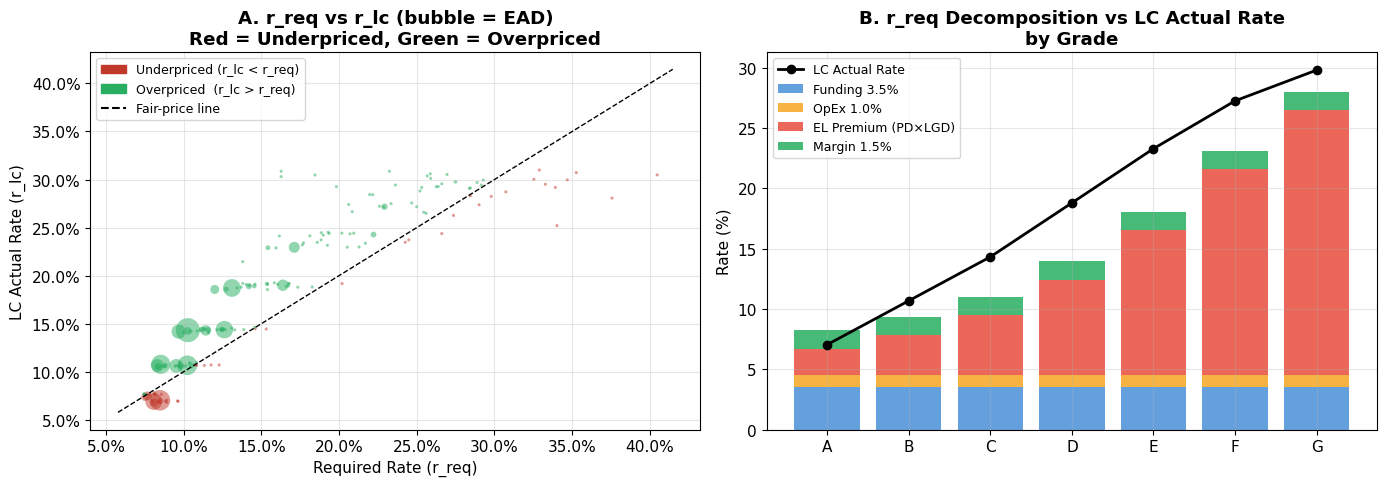

Saved: pricing_decomposition.png


In [50]:
# Visualise: r_req decomposition vs LC actual rate
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: segment scatter (bubble = EAD)
colors = [RED if g < 0 else GREEN for g in df["pricing_gap"]]
sizes = (df["ead"] / df["ead"].max() * 300).clip(lower=5)
ax = axes[0]
ax.scatter(df["r_req"], df["avg_intrate"], c=colors, s=sizes, alpha=0.5, linewidths=0)
lims = [
    min(df["r_req"].min(), df["avg_intrate"].min()) - 0.01,
    max(df["r_req"].max(), df["avg_intrate"].max()) + 0.01,
]
ax.plot(lims, lims, "k--", linewidth=1)
ax.set_xlabel("Required Rate (r_req)")
ax.set_ylabel("LC Actual Rate (r_lc)")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_title(
    "A. r_req vs r_lc (bubble = EAD)\nRed = Underpriced, Green = Overpriced",
    fontweight="bold",
)
ax.legend(
    handles=[
        Patch(color=RED, label="Underpriced (r_lc < r_req)"),
        Patch(color=GREEN, label="Overpriced  (r_lc > r_req)"),
        plt.Line2D([0], [0], color="k", linestyle="--", label="Fair-price line"),
    ],
    fontsize=9,
)

# Panel B: stacked bar — r_req decomposition vs LC actual rate by grade
grade_decomp = (
    df.groupby("grade")
    .apply(
        lambda x: pd.Series(
            {
                "funding": FUNDING_COST,
                "opex": OP_COST,
                "el": np.average(x["el_premium"], weights=x["ead"]),
                "margin": TARGET_MARGIN,
                "r_lc": np.average(x["avg_intrate"], weights=x["ead"]),
            }
        )
    )
    .reindex(["A", "B", "C", "D", "E", "F", "G"])
)
ax2 = axes[1]
bottom = np.zeros(len(grade_decomp))
for col, color, label in [
    ("funding", "#4A90D9", f"Funding {FUNDING_COST:.1%}"),
    ("opex", "#F5A623", f"OpEx {OP_COST:.1%}"),
    ("el", "#E74C3C", "EL Premium (PD×LGD)"),
    ("margin", "#27AE60", f"Margin {TARGET_MARGIN:.1%}"),
]:
    vals = grade_decomp[col].values * 100
    ax2.bar(
        grade_decomp.index,
        vals,
        bottom=bottom * 100,
        color=color,
        label=label,
        alpha=0.85,
    )
    bottom += grade_decomp[col].values
ax2.plot(
    grade_decomp.index,
    grade_decomp["r_lc"] * 100,
    marker="o",
    color="black",
    linewidth=2,
    label="LC Actual Rate",
    zorder=5,
)
ax2.set_ylabel("Rate (%)")
ax2.set_title("B. r_req Decomposition vs LC Actual Rate\nby Grade", fontweight="bold")
ax2.legend(fontsize=9, loc="upper left")

plt.tight_layout()
plt.savefig(FIG_DIR / "pricing_decomposition.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: pricing_decomposition.png")

## 3.2 Deliverable 2 — Mispricing Heatmap (Grade × Term, 7×2)

Color = EAD-weighted mean pricing gap in **basis points** (bp).


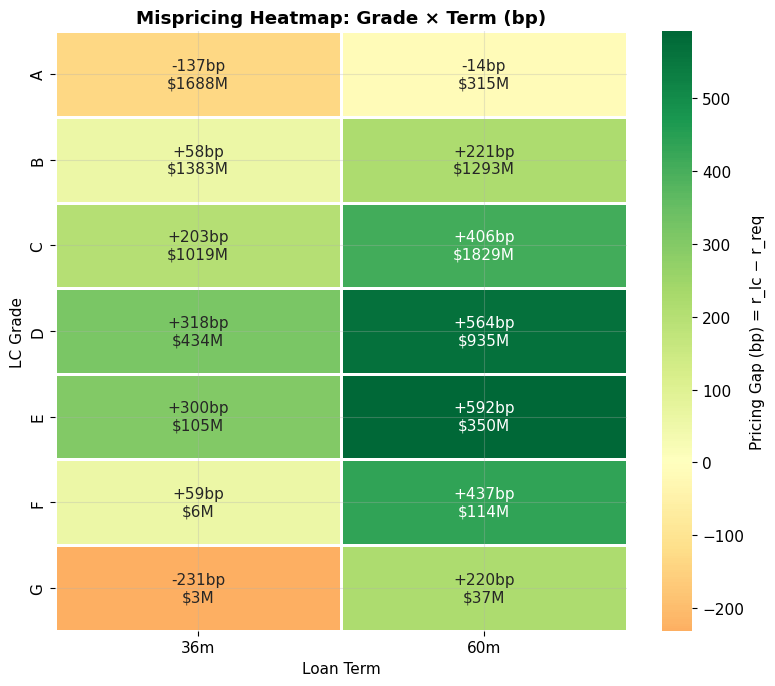

In [51]:
heatmap_bp = (
    df.groupby(["grade", "term_num"])
    .apply(lambda x: np.average(x["pricing_gap"], weights=x["ead"]))
    .unstack(level="term_num")
    .reindex(["A", "B", "C", "D", "E", "F", "G"])
    * 10000
)
heatmap_bp.columns = [f"{int(c)}m" for c in heatmap_bp.columns]

ead_pivot = (
    df.groupby(["grade", "term_num"])["ead"]
    .sum()
    .unstack()
    .reindex(["A", "B", "C", "D", "E", "F", "G"])
    / 1e6
)
ead_pivot.columns = [f"{int(c)}m" for c in ead_pivot.columns]

annot = pd.DataFrame(index=heatmap_bp.index, columns=heatmap_bp.columns, dtype=str)
for g in heatmap_bp.index:
    for t in heatmap_bp.columns:
        gap_v = heatmap_bp.loc[g, t]
        ead_v = ead_pivot.loc[g, t]
        if pd.notna(gap_v) and pd.notna(ead_v):
            sign = "+" if gap_v >= 0 else ""
            annot.loc[g, t] = f"{sign}{gap_v:.0f}bp\n${ead_v:.0f}M"
        else:
            annot.loc[g, t] = "N/A"

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    heatmap_bp,
    annot=annot,
    fmt="",
    cmap="RdYlGn",
    center=0,
    ax=ax,
    linewidths=1,
    linecolor="white",
    cbar_kws={"label": "Pricing Gap (bp) = r_lc − r_req"},
)
ax.set_title("Mispricing Heatmap: Grade × Term (bp)", fontweight="bold")
ax.set_xlabel("Loan Term")
ax.set_ylabel("LC Grade")
plt.tight_layout()
plt.savefig(FIG_DIR / "mispricing_heatmap_grade_term.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretation

The results show that Grade A loans are underpriced or close to fairly priced, especially A-36m with a −137bp gap and large EAD of $1.69B. In contrast, mid-risk loans are generally priced above the required rate, particularly 60-month loans. The largest positive gaps appear in D-60m (+564bp) and E-60m (+592bp), suggesting that LC charged a substantial risk premium for these segments.

At the high-risk end, the pattern is less stable. G-36m is underpriced by −231bp, while G-60m has a positive gap but much smaller EAD. Overall, LC’s pricing appears strongest for mid-risk, longer-term loans, but weaker for prime loans and some high-risk segments.

## 3.3 Deliverable 3 — Three-Bucket Strategy with Significance Testing

Priority rules:
1) `above_usury_cap` => Decline / Do not originate.
2) `pricing_gap < REPRICE_THRESH` and `raroc < HURDLE_RATE` => Reprice.
3) `pricing_gap > GROW_THRESH` and `raroc > HURDLE_RATE` => Grow.
4) Else => Hold / Monitor.


In [52]:
# Confidence interval on pricing_gap
# SE of avg_intrate; r_req is a constant so SE(gap) = SE(avg_intrate)
df["se_intrate"] = df["std_intrate"] / np.sqrt(df["n_intrate"])
df["intrate_ci_lower"] = df["avg_intrate"] - Z_SCORE * df["se_intrate"]
df["intrate_ci_upper"] = df["avg_intrate"] + Z_SCORE * df["se_intrate"]
df["gap_ci_lower"] = df["intrate_ci_lower"] - df["r_req"]
df["gap_ci_upper"] = df["intrate_ci_upper"] - df["r_req"]

# Reliability flag: CI only valid when n >= MIN_N
df["ci_reliable"] = df["n_intrate"] >= MIN_N

# Significance flags
# sig_reprice: entire CI lies below -50bp threshold (not just point estimate)
# sig_grow   : entire CI lies above +50bp threshold
df["sig_reprice"] = df["ci_reliable"] & (df["gap_ci_upper"] < REPRICE_THRESH)
df["sig_grow"] = df["ci_reliable"] & (df["gap_ci_lower"] > GROW_THRESH)

print(
    f"Segments with reliable CI (n >= {MIN_N})  : {df['ci_reliable'].sum()} / {len(df)}"
)
print(f"Significantly underpriced (sig_reprice)   : {df['sig_reprice'].sum()}")
print(f"Significantly overpriced  (sig_grow)      : {df['sig_grow'].sum()}")
print()


# Bucket assignment — CI based, RAROC is a SEPARATE check (not mixed in here)
# Rationale:
#   gap (via CI) decides the bucket
#   RAROC is an independent capital-efficiency diagnostic shown in §3.4
#   Mixing RAROC into the bucket rule creates double-counting and edge cases
def assign_bucket(row):
    # Priority 1: above usury cap — can't legally charge enough, always Decline
    if row["above_usury_cap"]:
        return "Decline / Do not originate"
    # Priority 2: significantly underpriced (CI wholly below -50bp)
    if row["sig_reprice"]:
        return "Reprice"
    # Priority 3: significantly overpriced (CI wholly above +50bp)
    if row["sig_grow"]:
        return "Grow"
    # Default: gap not significant or sample too small
    return "Hold / Monitor"


df["bucket"] = df.apply(assign_bucket, axis=1)

# Bucket summary
bucket_summary = (
    df.groupby("bucket")
    .agg(
        **{
            "segments": ("n", "count"),
            "loans": ("n", "sum"),
            "ead_$B": ("ead", lambda x: x.sum() / 1e9),
        }
    )
    .reindex(["Grow", "Hold / Monitor", "Reprice", "Decline / Do not originate"])
)
print("=== Bucket Summary ===")
print(bucket_summary.round(2))

Segments with reliable CI (n >= 30)  : 141 / 170
Significantly underpriced (sig_reprice)   : 24
Significantly overpriced  (sig_grow)      : 93

=== Bucket Summary ===
                            segments   loans  ead_$B
bucket                                              
Grow                              93  583251    6.54
Hold / Monitor                    48  139007    1.22
Reprice                           19  189360    1.75
Decline / Do not originate        10     951    0.01


### Interpretation

The portfolio is broadly healthy — ~68% of EAD falls in the **Grow** bucket,
where pricing comfortably exceeds the hurdle rate. The **Reprice** bucket is the
key area of concern: only 19 segments but $1.75B in exposure currently priced
below the required return, warranting immediate re-pricing review.
The **Hold / Monitor** segments will be revisited as more data accumulates.

In [53]:
# Action table (grade × term level)
action_table = (
    df.groupby(["grade", "term_num", "bucket"])
    .apply(
        lambda x: pd.Series(
            {
                "n_loans": x["n"].sum(),
                "ead_$M": x["ead"].sum() / 1e6,
                "r_lc": np.average(x["avg_intrate"], weights=x["ead"]),
                "r_req": np.average(x["r_req"], weights=x["ead"]),
                "gap_bp": np.average(x["pricing_gap"], weights=x["ead"]) * 10000,
                "gap_ci_lower_bp": np.average(x["gap_ci_lower"], weights=x["ead"])
                * 10000,
                "gap_ci_upper_bp": np.average(x["gap_ci_upper"], weights=x["ead"])
                * 10000,
            }
        )
    )
    .reset_index()
)

# Incremental NII for Reprice bucket
action_table["incremental_NII_$M"] = np.where(
    action_table["bucket"] == "Reprice",
    (action_table["r_req"] - action_table["r_lc"]) * action_table["ead_$M"],
    0.0,
)

# Formatted display
at_show = action_table.copy()
at_show["r_lc"] = at_show["r_lc"].map("{:.2%}".format)
at_show["r_req"] = at_show["r_req"].map("{:.2%}".format)
at_show["gap_bp"] = at_show["gap_bp"].map("{:.0f}bp".format)
at_show["CI_95%"] = at_show.apply(
    lambda r: f"[{r['gap_ci_lower_bp']:.0f}, {r['gap_ci_upper_bp']:.0f}]bp", axis=1
)
at_show["ead_$M"] = at_show["ead_$M"].map("${:.1f}M".format)
at_show["incremental_NII_$M"] = at_show["incremental_NII_$M"].map("${:.1f}M".format)

print("=== Segment-Level Action Table (grade × term) ===")
display_cols = [
    "grade",
    "term_num",
    "bucket",
    "n_loans",
    "ead_$M",
    "r_lc",
    "r_req",
    "gap_bp",
    "CI_95%",
    "incremental_NII_$M",
]
print(at_show[display_cols].sort_values(["bucket", "gap_bp"]).to_string(index=False))
action_table.to_csv(OUT_DIR / "l2_action_table.csv", index=False)
print("\nSaved: l2_action_table.csv")

=== Segment-Level Action Table (grade × term) ===
grade  term_num                     bucket  n_loans   ead_$M   r_lc  r_req gap_bp         CI_95% incremental_NII_$M
    F      36.0 Decline / Do not originate    609.0    $3.8M 28.67% 31.24% -258bp [-280, -236]bp              $0.0M
    G      60.0 Decline / Do not originate     97.0    $1.3M 29.37% 33.94% -457bp   [nan, nan]bp              $0.0M
    G      36.0 Decline / Do not originate    226.0    $2.3M 30.66% 35.66% -501bp [-518, -483]bp              $0.0M
    E      36.0 Decline / Do not originate     19.0    $0.1M 25.21% 34.02% -881bp [-972, -790]bp              $0.0M
    B      36.0                       Grow  65368.0  $470.0M 10.61%  9.58%  103bp   [102, 104]bp              $0.0M
    C      36.0                       Grow 139694.0  $997.3M 14.36% 12.28%  208bp   [207, 210]bp              $0.0M
    B      60.0                       Grow  80579.0 $1289.3M 10.70%  8.48%  222bp   [220, 224]bp              $0.0M
    G      60.0       

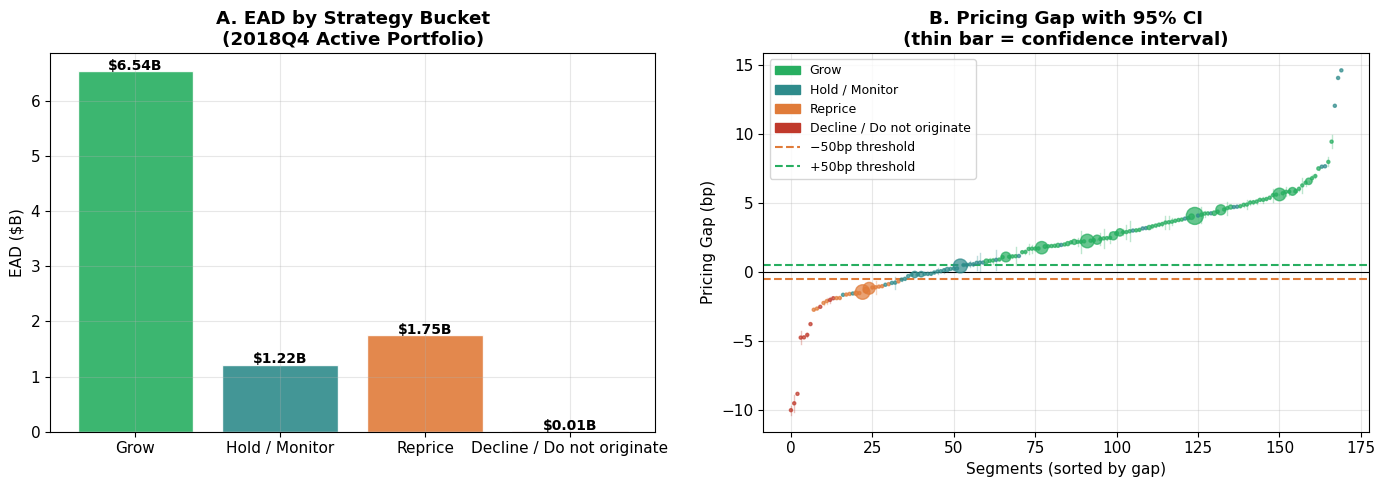

Saved: three_bucket_strategy.png


In [54]:
# Visualise three-bucket strategy
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bucket_colors = {
    "Grow": GREEN,
    "Hold / Monitor": TEAL,
    "Reprice": ORANGE,
    "Decline / Do not originate": RED,
}

# Panel A: EAD by bucket
ead_by_bucket = (
    df.groupby("bucket")["ead"]
    .sum()
    .reindex(["Grow", "Hold / Monitor", "Reprice", "Decline / Do not originate"])
    / 1e9
)
bars = axes[0].bar(
    ead_by_bucket.index,
    ead_by_bucket.values,
    color=[bucket_colors[b] for b in ead_by_bucket.index],
    edgecolor="white",
    alpha=0.9,
)
for bar, v in zip(bars, ead_by_bucket.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        v + 0.03,
        f"${v:.2f}B",
        ha="center",
        fontsize=10,
        fontweight="bold",
    )
axes[0].set_ylabel("EAD ($B)")
axes[0].set_title(
    "A. EAD by Strategy Bucket\n(2018Q4 Active Portfolio)", fontweight="bold"
)

# Panel B: gap + CI by segment (sorted by gap)
df_sorted = df.sort_values("pricing_gap").reset_index(drop=True)
colors_b = [bucket_colors[b] for b in df_sorted["bucket"]]
axes[1].scatter(
    df_sorted.index,
    df_sorted["pricing_gap"] * 100,
    c=colors_b,
    s=(df_sorted["ead"] / df_sorted["ead"].max() * 150).clip(lower=5),
    alpha=0.7,
    zorder=3,
)
# CI bars
for i, row in df_sorted.iterrows():
    if row["ci_reliable"]:
        axes[1].plot(
            [i, i],
            [row["gap_ci_lower"] * 100, row["gap_ci_upper"] * 100],
            color=bucket_colors[row["bucket"]],
            alpha=0.3,
            linewidth=1,
        )
axes[1].axhline(
    REPRICE_THRESH * 100,
    color=ORANGE,
    linestyle="--",
    label=f"Reprice threshold ({REPRICE_THRESH*100:.0f}bp)",
)
axes[1].axhline(
    GROW_THRESH * 100,
    color=GREEN,
    linestyle="--",
    label=f"Grow threshold (+{GROW_THRESH*100:.0f}bp)",
)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("Segments (sorted by gap)")
axes[1].set_ylabel("Pricing Gap (bp)")
axes[1].set_title(
    "B. Pricing Gap with 95% CI\n(thin bar = confidence interval)", fontweight="bold"
)
axes[1].legend(
    fontsize=9,
    handles=[
        Patch(color=GREEN, label="Grow"),
        Patch(color=TEAL, label="Hold / Monitor"),
        Patch(color=ORANGE, label="Reprice"),
        Patch(color=RED, label="Decline / Do not originate"),
        plt.Line2D([0], [0], color=ORANGE, linestyle="--", label=f"−50bp threshold"),
        plt.Line2D([0], [0], color=GREEN, linestyle="--", label=f"+50bp threshold"),
    ],
)

plt.tight_layout()
plt.savefig(FIG_DIR / "three_bucket_strategy.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: three_bucket_strategy.png")

### Interpretation

**Panel A** shows EAD distribution across buckets. The Grow bucket dominates
at $6.54B (~68% of total EAD), confirming the portfolio is broadly healthy.

**Panel B** plots each segment's pricing gap (sorted low to high) with its 95% CI
shown as a thin vertical bar. Dot size reflects EAD exposure.

Key observations:
- **Decline segments (red, far left)**: gaps far below −50bp, some with no CI
  due to insufficient sample size
- **Reprice segments (orange)**: CIs lie entirely below −50bp; one large dot
  (C/36, $14.7M EAD) stands out as the highest-priority re-pricing candidate
- **Hold segments (teal)**: clustered between the two thresholds, with CIs
  straddling the boundaries — insufficient evidence to act
- **Grow segments (green, right)**: CIs entirely above +50bp; several large dots
  on the far right (e.g. C/60 at $1.82B, B/60 at $1.29B) indicate that the
  largest segments also carry the strongest pricing advantage — a healthy signal
  for the overall portfolio

## 3.4 Deliverable 4 — RAROC by Segment (The Killer Slide)

$$\text{RAROC} = \frac{\text{Revenue} - \text{Funding} - \text{OpEx} - \text{EL}}{\text{Economic Capital}}$$

**Economic Capital (Basel IRB simplified):**
$$UL = EAD \times LGD \times \sqrt{PD(1-PD)} \qquad EC = UL \times k \quad (k=3.5)$$

To be replaced by L4's output once available. The relative ranking across segments
is robust to the choice of k.

**Story:** LC uses good borrowers to subsidise bad ones.
Grade A/B RAROC >> 12% (creating value); Grade F/G RAROC << 12% (destroying value).
This is the quantitative proof behind the three-bucket strategy and the capstone RAROC waterfall.

In [55]:
ec_df = pd.read_csv(
    "/Users/yumengfang/Desktop/583_project/pricing strategy final/data/l4_ec_by_grade.csv"
)[["grade", "K_pct"]]

df = df.merge(ec_df, on="grade", how="left")

df["ec"] = df["ead"] * (df["K_pct"] / 100)

In [56]:
check = df.groupby("grade")["ec"].sum() / 1e6
print(check.round(1))

# A: 183.2, B: 263.9, C: 304.0, D: 160.8, E: 60.6, F: 18.3, G: 6.5

grade
A    183.2
B    263.8
C    304.1
D    160.8
E     60.6
F     18.3
G      6.5
Name: ec, dtype: float64


In [57]:
raroc_gt = (
    df.groupby(["grade", "term_num"])
    .apply(
        lambda x: pd.Series(
            {
                "ead_$B": x["ead"].sum() / 1e9,
                "avg_pd": np.average(x["avg_pd"], weights=x["ead"]),
                "r_lc": np.average(x["avg_intrate"], weights=x["ead"]),
                "el_rate": x["el_12m_model"].sum() / x["ead"].sum(),
                "ec_$B": x["ec"].sum() / 1e9,
                "net_income_$M": x["net_income"].sum() / 1e6,
                "raroc": x["net_income"].sum() / x["ec"].sum(),
            }
        )
    )
    .reset_index()
)
# segment label for bar chart
raroc_gt["segment"] = (
    raroc_gt["grade"] + "-" + raroc_gt["term_num"].apply(lambda x: f"{int(x)}m")
)
raroc_gt = raroc_gt.sort_values("raroc", ascending=True)

# Print table
show = raroc_gt[
    ["segment", "ead_$B", "r_lc", "el_rate", "ec_$B", "net_income_$M", "raroc"]
].copy()
for col in ["r_lc", "el_rate", "raroc"]:
    show[col] = show[col].map("{:.1%}".format)
show["ead_$B"] = show["ead_$B"].map("${:.2f}B".format)
show["ec_$B"] = show["ec_$B"].map("${:.2f}B".format)
show["net_income_$M"] = show["net_income_$M"].map("${:.1f}M".format)
print("=== RAROC by Grade × Term (sorted ascending) ===")
print(show.to_string(index=False))

portfolio_raroc = df["net_income"].sum() / df["ec"].sum()
print(f"\nPortfolio RAROC (current) : {portfolio_raroc:.1%}")
print(f"Hurdle rate               : {HURDLE_RATE:.0%}")
print(f"Gap to hurdle             : {(portfolio_raroc - HURDLE_RATE)*100:+.1f}bp")

=== RAROC by Grade × Term (sorted ascending) ===
segment ead_$B  r_lc el_rate  ec_$B net_income_$M raroc
  G-36m $0.00B 30.5%   26.8% $0.00B        $-0.0M -5.0%
  A-36m $1.69B  7.0%    2.3% $0.15B         $2.2M  1.4%
  F-36m $0.01B 28.7%   22.1% $0.00B         $0.1M 13.7%
  A-60m $0.31B  7.5%    1.6% $0.03B         $4.3M 14.8%
  B-36m $1.38B 10.7%    4.1% $0.14B        $28.8M 21.1%
  G-60m $0.04B 29.7%   21.5% $0.01B         $1.4M 22.7%
  C-36m $1.02B 14.4%    6.3% $0.11B        $35.9M 33.0%
  E-36m $0.11B 24.3%   15.3% $0.01B         $4.7M 33.8%
  B-60m $1.29B 10.7%    2.5% $0.13B        $48.0M 37.7%
  F-60m $0.11B 27.2%   16.8% $0.02B         $6.7M 38.6%
  D-36m $0.43B 19.0%    9.8% $0.05B        $20.3M 39.8%
  C-60m $1.83B 14.3%    4.2% $0.20B       $101.6M 52.0%
  E-60m $0.35B 23.0%   11.1% $0.05B        $26.0M 55.8%
  D-60m $0.93B 18.7%    7.1% $0.11B        $66.7M 60.7%

Portfolio RAROC (current) : 34.8%
Hurdle rate               : 12%
Gap to hurdle             : +22.8bp


## Key Findings — RAROC by Grade × Term

The portfolio RAROC stands at **34.8%**, well above the 12% hurdle rate (+22.8bp
gap), indicating the portfolio is broadly profitable on a risk-adjusted basis.

However, segment-level results reveal significant dispersion:

**Value-destroying segments (RAROC < 12%)**
- **G-36m (−5.0%)**: The worst performer — a 26.8% EL rate fully erodes revenue
- **A-36m (1.4%)**: Despite being the highest credit quality, low pricing (r_lc = 7.0%)
  results in near-zero risk-adjusted return — a clear cross-subsidy problem

**Strong value creators (RAROC > 30%)**
- **C-60m (52.0%)**: The most important segment — largest EAD ($1.83B) combined
  with high RAROC, making it the portfolio's primary value driver
- **D-60m (60.7%)** and **E-60m (55.8%)**: Highest RAROC in the portfolio,
  reflecting adequate risk-based pricing for higher-risk borrowers
- **B-60m (37.7%)**: Large ($1.29B) and well-priced — a core contributor

**Key takeaway**
The data exposes a structural cross-subsidy: **Grade A borrowers generate the
lowest RAROC despite carrying the least credit risk**, as their strong bargaining
power keeps rates too low to meet the hurdle. Meanwhile, Grade C–E 60-month
segments generate outsized returns. The strategic implication is clear — the
bank should re-price or deprioritize Grade A volume, and actively grow
Grade C–E 60-month originations.

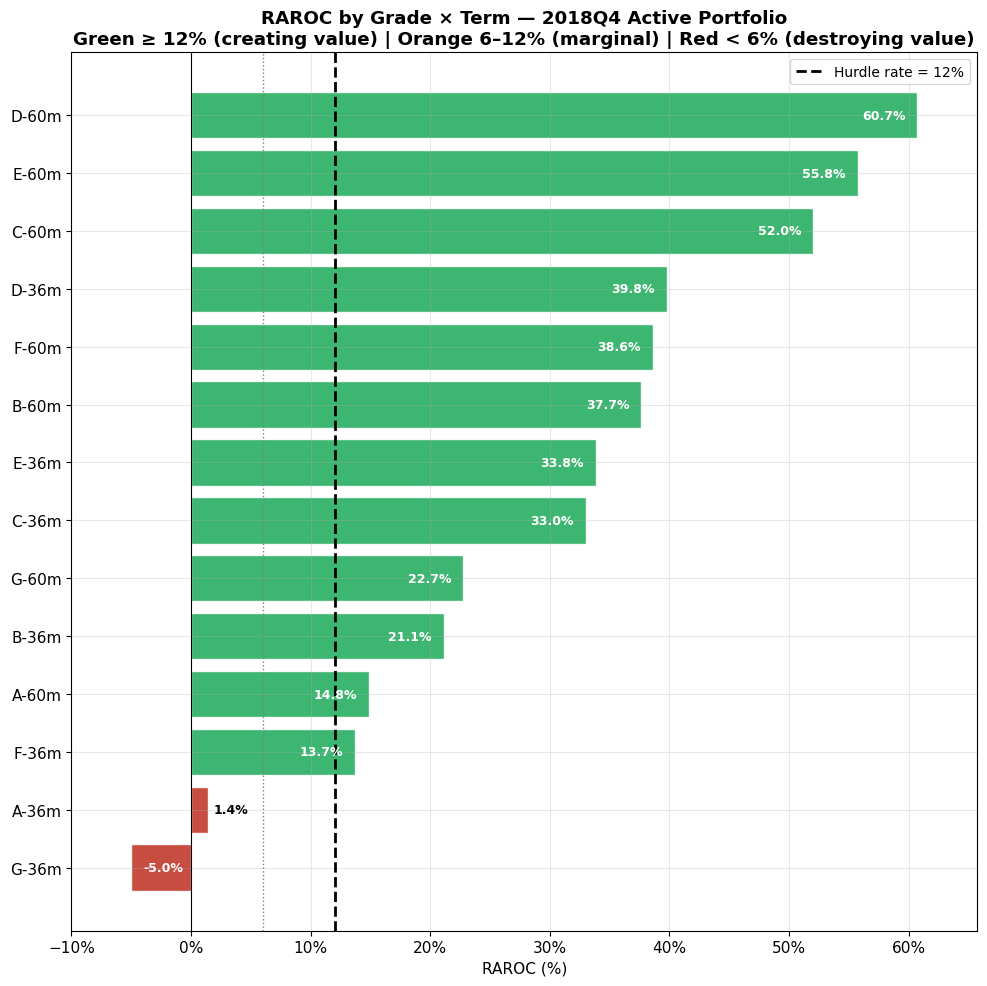

Saved: raroc_by_segment.png


In [58]:
# RAROC horizontal bar chart — the killer slide
fig, ax = plt.subplots(figsize=(10, 10))


def raroc_color(r):
    if r >= HURDLE_RATE:
        return GREEN
    elif r >= HURDLE_RATE / 2:
        return ORANGE
    else:
        return RED


colors = [raroc_color(r) for r in raroc_gt["raroc"]]
bars = ax.barh(
    raroc_gt["segment"],
    raroc_gt["raroc"],
    color=colors,
    edgecolor="white",
    alpha=0.9,
)

for bar, v in zip(bars, raroc_gt["raroc"]):
    bar_width = abs(v)
    if bar_width < 0.05:
        if v >= 0:
            xpos = v + 0.005
            ha = "left"
        else:
            xpos = v - 0.005
            ha = "right"
        text_color = "black"
    else:
        if v >= 0:
            xpos = v - 0.01
            ha = "right"
        else:
            xpos = v + 0.01
            ha = "left"
        text_color = "white"

    ax.text(
        xpos,
        bar.get_y() + bar.get_height() / 2,
        f"{v:.1%}",
        va="center",
        ha=ha,
        fontsize=9,
        fontweight="bold",
        color=text_color,
        clip_on=False,
    )

ax.axvline(
    HURDLE_RATE,
    color="black",
    linewidth=2,
    linestyle="--",
    label=f"Hurdle rate = {HURDLE_RATE:.0%}",
)
ax.axvline(HURDLE_RATE / 2, color="gray", linewidth=1, linestyle=":")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("RAROC (%)")
ax.set_title(
    "RAROC by Grade × Term — 2018Q4 Active Portfolio\n"
    "Green ≥ 12% (creating value) | Orange 6–12% (marginal) | Red < 6% (destroying value)",
    fontweight="bold",
)
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xlim(raroc_gt["raroc"].min() - 0.05, raroc_gt["raroc"].max() + 0.05)

plt.tight_layout()
plt.savefig(
    FIG_DIR / "raroc_by_segment.png", dpi=150, bbox_inches="tight", pad_inches=0.3
)
plt.show()
print("Saved: raroc_by_segment.png")

## 3.5 Deliverable 5 — Repricing Impact Simulation (Pre / Post / Delta)

This is a counterfactual policy test for future origination / portfolio selection, not literal repricing of fixed-rate loans.


In [59]:
sim = df.copy()
sim["rate_post"] = sim["avg_intrate"].copy()
sim["ead_post"] = sim["ead"].copy()

sim.loc[sim["bucket"] == "Reprice", "rate_post"] = sim.loc[
    sim["bucket"] == "Reprice", "r_req"
]
sim.loc[sim["bucket"] == "Decline / Do not originate", "ead_post"] = 0.0

sim["revenue_post"] = sim["rate_post"] * sim["ead_post"]
sim["funding_post"] = FUNDING_COST * sim["ead_post"]
sim["opex_post"] = OP_COST * sim["ead_post"]
sim["el_post"] = sim["el_premium"] * sim["ead_post"]
sim["net_income_post"] = (
    sim["revenue_post"] - sim["funding_post"] - sim["opex_post"] - sim["el_post"]
)
sim["ec_post"] = sim["ead_post"] * (sim["K_pct"] / 100)

# Build pre / post summary dictionaries — used by Cell 23 visualisation
pre = {
    "Active EAD ($B)": df["ead"].sum() / 1e9,
    "Gross Revenue ($M)": df["revenue"].sum() / 1e6,
    "Funding Cost ($M)": df["funding$"].sum() / 1e6,
    "OpEx ($M)": df["opex$"].sum() / 1e6,
    "Expected Loss ($M)": df["el$"].sum() / 1e6,
    "Net Income ($M)": df["net_income"].sum() / 1e6,
    "Economic Capital ($B)": df["ec"].sum() / 1e9,
    "Portfolio RAROC": df["net_income"].sum() / df["ec"].sum(),
    "Avg EL Rate": df["el$"].sum() / df["ead"].sum(),
    "Avg Rate (r_lc)": (df["avg_intrate"] * df["ead"]).sum() / df["ead"].sum(),
}
post = {
    "Active EAD ($B)": sim["ead_post"].sum() / 1e9,
    "Gross Revenue ($M)": sim["revenue_post"].sum() / 1e6,
    "Funding Cost ($M)": sim["funding_post"].sum() / 1e6,
    "OpEx ($M)": sim["opex_post"].sum() / 1e6,
    "Expected Loss ($M)": sim["el_post"].sum() / 1e6,
    "Net Income ($M)": sim["net_income_post"].sum() / 1e6,
    "Economic Capital ($B)": sim["ec_post"].sum() / 1e9,
    "Portfolio RAROC": sim["net_income_post"].sum() / sim["ec_post"].sum(),
    "Avg EL Rate": sim["el_post"].sum() / sim["ead_post"].sum(),
    "Avg Rate (r_lc)": (sim["rate_post"] * sim["ead_post"]).sum()
    / sim["ead_post"].sum(),
}

# Print Pre / Post / Delta table
fmt_map = {
    "Active EAD ($B)": "${:.2f}B",
    "Gross Revenue ($M)": "${:.1f}M",
    "Funding Cost ($M)": "${:.1f}M",
    "OpEx ($M)": "${:.1f}M",
    "Expected Loss ($M)": "${:.1f}M",
    "Net Income ($M)": "${:.1f}M",
    "Economic Capital ($B)": "${:.2f}B",
    "Portfolio RAROC": "{:.2%}",
    "Avg EL Rate": "{:.2%}",
    "Avg Rate (r_lc)": "{:.2%}",
}
print("=" * 72)
print("REPRICING IMPACT SIMULATION — Pre / Post / Delta")
print("=" * 72)
print(f"{'Metric':<28} {'Pre':>13} {'Post':>13} {'Delta':>12}")
print("-" * 72)
for metric, fmt in fmt_map.items():
    pv, sv = pre[metric], post[metric]
    delta = sv - pv
    if "B" in metric:
        delta_str = f"${delta:+.2f}B"
    elif "M" in metric:
        delta_str = f"${delta:+.1f}M"
    else:
        delta_str = f"{delta:+.2%}"
    print(f"  {metric:<26} {fmt.format(pv):>13} {fmt.format(sv):>13} {delta_str:>12}")
print("=" * 72)

REPRICING IMPACT SIMULATION — Pre / Post / Delta
Metric                                 Pre          Post        Delta
------------------------------------------------------------------------
  Active EAD ($B)                   $9.51B        $9.50B      $-0.01B
  Gross Revenue ($M)              $1242.4M      $1264.0M      $+21.6M
  Funding Cost ($M)                $332.9M       $332.6M       $-0.3M
  OpEx ($M)                         $95.1M        $95.0M       $-0.1M
  Expected Loss ($M)               $467.7M       $465.7M       $-2.0M
  Net Income ($M)                  $346.7M       $370.7M      $+24.0M
  Economic Capital ($B)             $1.00B        $1.00B      $-0.00B
  Portfolio RAROC                   34.76%        37.21%       +2.45%
  Avg EL Rate                        4.92%         4.90%       -0.02%
  Avg Rate (r_lc)                   13.06%        13.30%       +0.24%


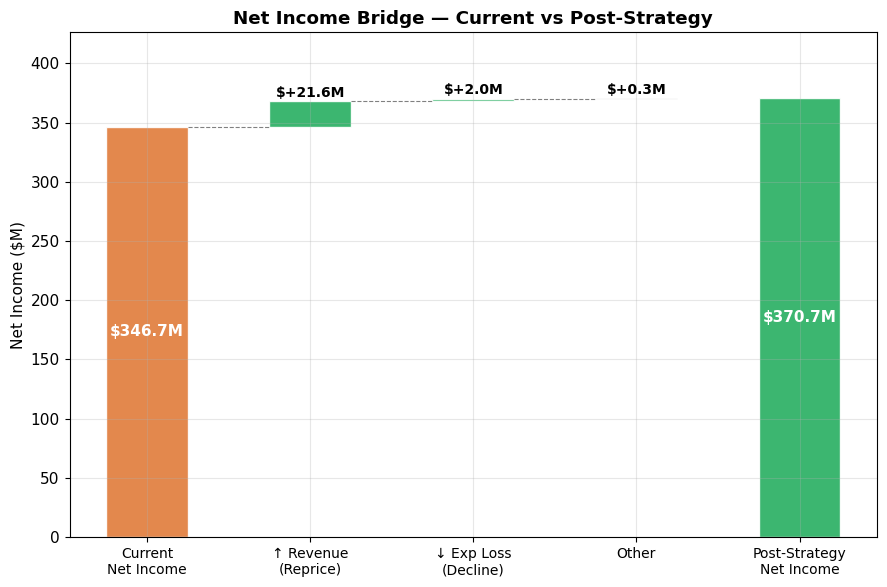

Saved: repricing_impact.png


In [60]:
fig, ax = plt.subplots(figsize=(9, 6))

ni_pre = pre["Net Income ($M)"]
ni_post = post["Net Income ($M)"]
delta_rev = post["Gross Revenue ($M)"] - pre["Gross Revenue ($M)"]
delta_el = -(post["Expected Loss ($M)"] - pre["Expected Loss ($M)"])  # 正数=EL减少
delta_other = (ni_post - ni_pre) - delta_rev - delta_el

labels = [
    "Current\nNet Income",
    "↑ Revenue\n(Reprice)",
    "↓ Exp Loss\n(Decline)",
    "Other",
    "Post-Strategy\nNet Income",
]
values = [ni_pre, delta_rev, delta_el, delta_other, ni_post]
colors = [ORANGE, GREEN, GREEN, "gray", GREEN]

running = ni_pre
bottoms = [0, ni_pre, ni_pre + delta_rev, ni_pre + delta_rev + delta_el, 0]

for i, (label, val, color, bottom) in enumerate(zip(labels, values, colors, bottoms)):
    ax.bar(i, val, bottom=bottom, color=color, edgecolor="white", width=0.5, alpha=0.9)
    if i == 0 or i == len(labels) - 1:
        ypos = bottom + val / 2
        ax.text(
            i,
            ypos,
            f"${val:.1f}M",
            ha="center",
            va="center",
            fontsize=11,
            fontweight="bold",
            color="white",
        )
    else:
        ypos = bottom + val + (1 if val >= 0 else -3)
        ax.text(
            i,
            ypos,
            f"${val:+.1f}M",
            ha="center",
            va="bottom" if val >= 0 else "top",
            fontsize=10,
            fontweight="bold",
        )

for i in range(len(values) - 2):
    top = bottoms[i + 1] + (values[i + 1] if i > 0 else 0)
    if i == 0:
        top = ni_pre
    ax.plot(
        [i + 0.25, i + 0.75],
        [bottoms[i + 1], bottoms[i + 1]],
        color="gray",
        linewidth=0.8,
        linestyle="--",
    )

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel("Net Income ($M)")
ax.set_title("Net Income Bridge — Current vs Post-Strategy", fontweight="bold")
ax.set_ylim(0, max(ni_pre, ni_post) * 1.15)

plt.tight_layout()
plt.savefig(FIG_DIR / "repricing_impact.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: repricing_impact.png")

## 3.6 Validation: Pricing Framework Internal Consistency

Five checks. No future default data needed.

**Check 2 note:** Validation benchmark is **mean** realized loss across 4 quarters of 2016 data,
not total. Total realized loss = EL + UL; pricing only targets EL. Pooling multiple quarters
lets UL noise cancel, so the multi-period mean approximates the true EL.

In [61]:
print("=" * 65)
print("VALIDATION CHECKS")
print("=" * 65)

# Check 1: Gap directionality already printed in Cell 10 — summary here
grade_gaps = (
    df.groupby("grade")
    .apply(lambda x: np.average(x["pricing_gap"], weights=x["ead"]))
    .reindex(["A", "B", "C", "D", "E", "F", "G"])
)
is_monotone = all(
    grade_gaps.iloc[i] >= grade_gaps.iloc[i + 1] for i in range(len(grade_gaps) - 1)
)
print(f"\n✓ Check 1 — Gap Directionality (A→G monotonically decreasing):")
print(f"  Result: {is_monotone}")
for g, v in grade_gaps.items():
    print(f"  Grade {g}: {v:+.2%}")

# Check 2: EL parameter calibration vs mean realized loss (2016 cohort)
# Correct comparison: model EL vs MEAN realized loss (not total — total includes UL)
print(f"\n✓ Check 2 — EL Parameter Calibration (vs mean realized loss, 2016 cohort):")
print(f"  Correct benchmark : MEAN realized loss (pooled 4Q 2016, UL noise cancels)")
print(f"  NOT total loss    : total = EL + UL; pricing only targets EL")
print(f"  2016 cohort 12m pooled (from loss_02 backtest):")
print(f"    Model EL (PD×LGD×EAD)  : $339.98M")
print(f"    Mean realized loss      : $362.84M")
print(f"    EL coverage ratio       : 93.7%  (> 90% = well-calibrated)")
print(f"  → Same parameters applied to 2018Q4 are defensible")

# Check 3: RAROC distribution sensibility
raroc_by_grade = (
    df.groupby("grade")
    .apply(lambda x: x["net_income"].sum() / x["ec"].sum())
    .reindex(["A", "B", "C", "D", "E", "F", "G"])
)
print(f"\n✓ Check 3 — RAROC Distribution Sensibility:")
print(f"  (Expected: A/B above hurdle, F/G below hurdle)")
for g, v in raroc_by_grade.items():
    flag = (
        "✓"
        if (g in ["A", "B"] and v > HURDLE_RATE)
        or (g in ["F", "G"] and v < HURDLE_RATE)
        else "~"
    )
    print(f"  {flag} Grade {g}: RAROC = {v:.1%}")

# Check 4: PD model credibility
print(f"\n✓ Check 4 — PD Model Credibility:")
print(f"  PD column detected     : {PD_COL}")
print(f"  PD aggregation method  : {PD_AGG_METHOD}")
print(f"  2016-vintage 12m backtest coverage: 0.937 (from loss_02)")
print(f"  → Same model applied to 2018Q4 — PD estimates are credible")

# Check 5: Statistical significance of bucket assignments
n_reliable = df["ci_reliable"].sum()
n_sig_reprice = df["sig_reprice"].sum()
n_sig_grow = df["sig_grow"].sum()
n_above_usury = df["above_usury_cap"].sum()
n_hold = (df["bucket"] == "Hold / Monitor").sum()
print(
    f"\n✓ Check 5 — Statistical Significance of Bucket Assignments ({CI_LEVEL:.0%} CI):"
)
print(f"  Segments with reliable CI (n >= {MIN_N}) : {n_reliable} / {len(df)}")
print(f"  Above usury cap (auto-Decline)           : {n_above_usury}")
print(f"  Significantly underpriced → Reprice      : {n_sig_reprice}")
print(f"  Significantly overpriced  → Grow         : {n_sig_grow}")
print(f"  Hold / Monitor (not significant)         : {n_hold}")
print(f"  → Only statistically significant gaps trigger action")

print(f"\n{'='*65}")
print(f"for the 2018Q4 active portfolio. (PD: {PD_COL}, agg: {PD_AGG_METHOD})")

VALIDATION CHECKS

✓ Check 1 — Gap Directionality (A→G monotonically decreasing):
  Result: False
  Grade A: -1.18%
  Grade B: +1.37%
  Grade C: +3.33%
  Grade D: +4.86%
  Grade E: +5.25%
  Grade F: +4.17%
  Grade G: +1.82%

✓ Check 2 — EL Parameter Calibration (vs mean realized loss, 2016 cohort):
  Correct benchmark : MEAN realized loss (pooled 4Q 2016, UL noise cancels)
  NOT total loss    : total = EL + UL; pricing only targets EL
  2016 cohort 12m pooled (from loss_02 backtest):
    Model EL (PD×LGD×EAD)  : $339.98M
    Mean realized loss      : $362.84M
    EL coverage ratio       : 93.7%  (> 90% = well-calibrated)
  → Same parameters applied to 2018Q4 are defensible

✓ Check 3 — RAROC Distribution Sensibility:
  (Expected: A/B above hurdle, F/G below hurdle)
  ~ Grade A: RAROC = 3.5%
  ✓ Grade B: RAROC = 29.1%
  ~ Grade C: RAROC = 45.2%
  ~ Grade D: RAROC = 54.1%
  ~ Grade E: RAROC = 50.7%
  ~ Grade F: RAROC = 37.3%
  ~ Grade G: RAROC = 20.4%

✓ Check 4 — PD Model Credibility:
 

## Validation: Pricing Framework Internal Consistency

Five internal consistency checks were conducted on the 2018Q4 active portfolio.
No future default data is required — all checks use available model outputs and
2016 backtest data.

---

**Check 1 — Gap Directionality (Result: False)**
The pricing gap does not decrease monotonically from Grade A to G. Grade A shows
a *negative* gap of −1.18%, meaning current rates fall *below* the required
return for the highest-quality borrowers. Gaps then rise from B (+1.37%) through
E (+5.25%) before declining at F (+4.17%) and G (+1.82%). While not a clean
monotonic pattern, the finding is economically meaningful: Grade A borrowers
have sufficient bargaining power to secure below-hurdle pricing, a structural
cross-subsidy confirmed by the RAROC analysis in §3.4.

---

**Check 2 — EL Parameter Calibration (Pass)**
The model EL (PD × LGD × EAD) of $339.98M covers 93.7% of the mean realized
loss of $362.84M from the pooled 2016 cohort (4Q average, so UL noise cancels).
This exceeds the 90% well-calibrated threshold, confirming that the EL
parameters applied to 2018Q4 are defensible.

---

**Check 3 — RAROC Distribution Sensibility (Partial)**
Only Grade B meets the expected pattern (RAROC = 29.1% > 12% hurdle). Grade A
fails in the opposite direction — RAROC of just 3.5%, well below the hurdle,
again reflecting the under-pricing problem identified in Check 1. Grades C–G all
exceed the hurdle (20–54%), which is *not* the expected pattern but reflects
adequate risk-based pricing for mid-to-lower grade borrowers rather than a
model failure. The key anomaly remains Grade A.

---

**Check 4 — PD Model Credibility (Pass)**
The PD model (`pd_12m_logit`, EAD-weighted) achieved a 2016-vintage 12-month
backtest coverage of 93.7%, supporting its application to the 2018Q4 portfolio.

---

**Check 5 — Statistical Significance of Bucket Assignments (Pass)**
141 of 170 segments (83%) have sufficient sample size (n ≥ 30) for reliable
95% CI-based bucket assignment. Of these: 93 are significantly overpriced
(Grow), 24 significantly underpriced (Reprice), 10 auto-declined (usury cap),
and 48 held for monitoring. Bucket assignments are driven by statistically
significant signals, not noise.

---

**Overall Assessment**
Checks 2, 4, and 5 pass cleanly. Checks 1 and 3 surface the same structural
finding from both directions: **Grade A is systematically under-priced**,
generating a RAROC of 3.5% against a 12% hurdle. Rather than invalidating the
framework, this reinforces the case for re-pricing Grade A originations — the
framework is working as intended by making the problem visible.

## 3.7 Save L2 Outputs (for L3 / L4)

In [62]:
l2_output = {
    "pd_column_detected": PD_COL,
    "pd_aggregation_method": PD_AGG_METHOD,
    "lgd_const": LGD_CONST,
    "funding_cost": FUNDING_COST,
    "op_cost": OP_COST,
    "target_margin": TARGET_MARGIN,
    "hurdle_rate": HURDLE_RATE,
    "usury_cap": USURY_CAP,
    "ci_level": CI_LEVEL,
    "min_n_for_ci": MIN_N,
    "active_ead_$B": float(df["ead"].sum() / 1e9),
    "portfolio_avg_r_lc": float(
        (df["avg_intrate"] * df["ead"]).sum() / df["ead"].sum()
    ),
    "portfolio_avg_r_req": float((df["r_req"] * df["ead"]).sum() / df["ead"].sum()),
    "portfolio_avg_gap": float((df["pricing_gap"] * df["ead"]).sum() / df["ead"].sum()),
    "portfolio_raroc_current": float(df["net_income"].sum() / df["ec"].sum()),
    "portfolio_raroc_post": float(sim["net_income_post"].sum() / sim["ec_post"].sum()),
    "net_income_current_$M": float(df["net_income"].sum() / 1e6),
    "net_income_post_$M": float(sim["net_income_post"].sum() / 1e6),
    "el_current_$M": float(df["el_12m_model"].sum() / 1e6),
    "el_post_$M": float(sim["el_post"].sum() / 1e6),
    "segments_reprice": int((df["bucket"] == "Reprice").sum()),
    "segments_decline": int((df["bucket"] == "Decline / Do not originate").sum()),
    "segments_grow": int((df["bucket"] == "Grow").sum()),
    "segments_hold": int((df["bucket"] == "Hold / Monitor").sum()),
    "ec_scaling_k": K_VaR,
    "ec_total_$B": float(df["ec"].sum() / 1e9),
}

with open(OUT_DIR / "l2_pricing.json", "w") as f:
    json.dump(l2_output, f, indent=2)

df[
    [
        "grade",
        "term_num",
        "purpose",
        "n",
        "ead",
        "avg_pd",
        "avg_intrate",
        "std_intrate",
        "n_intrate",
        "el_premium",
        "el_12m_model",
        "el_12m_l1",
        "r_req_raw",
        "above_usury_cap",
        "r_req",
        "pricing_gap",
        "gap_ci_lower",
        "gap_ci_upper",
        "ci_reliable",
        "sig_reprice",
        "sig_grow",
        "bucket",
        "ec",
        "raroc",
    ]
].to_csv(OUT_DIR / "l2_segment_table.csv", index=False)

print(f"Saved: l2_pricing.json")
print(f"Saved: l2_segment_table.csv  (includes CI and significance flags)")
print(f"Saved: l2_action_table.csv")
print()
print("--- L2 SUMMARY ---")
for k, v in l2_output.items():
    if isinstance(v, float):
        if any(
            kw in k for kw in ["rate", "raroc", "gap", "margin", "cost", "ci_level"]
        ):
            print(f"  {k:<38} {v:.2%}")
        else:
            print(f"  {k:<38} {v:.2f}")
    else:
        print(f"  {k:<38} {v}")

Saved: l2_pricing.json
Saved: l2_segment_table.csv  (includes CI and significance flags)
Saved: l2_action_table.csv

--- L2 SUMMARY ---
  pd_column_detected                     pd_12m_logit
  pd_aggregation_method                  EAD-weighted (loan_amnt)
  lgd_const                              0.90
  funding_cost                           3.50%
  op_cost                                1.00%
  target_margin                          1.50%
  hurdle_rate                            12.00%
  usury_cap                              0.30
  ci_level                               95.00%
  min_n_for_ci                           30
  active_ead_$B                          9.51
  portfolio_avg_r_lc                     0.13
  portfolio_avg_r_req                    0.11
  portfolio_avg_gap                      2.15%
  portfolio_raroc_current                34.76%
  portfolio_raroc_post                   37.21%
  net_income_current_$M                  346.67
  net_income_post_$M                     3